In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load your data
df = pd.read_csv('C:/Users/DELL/Downloads/Legal Case/processed_data/clean_legal_cases.csv')

print("=" * 70)
print("LEGAL CORPUS ANALYSIS REPORT")
print("=" * 70)
print(f"\n📊 Dataset Overview:")
print(f"   Total Cases: {len(df):,}")
print(f"   Sources: {df['Source_Folder'].nunique()}")
print(f"   Date Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"   Courts: {df['Court'].nunique()}")
print(f"\n📝 Text Statistics:")
print(f"   Avg Text Length: {df['Case_Text_Full_Length'].mean():.0f} chars")
print(f"   Max Text Length: {df['Case_Text_Full_Length'].max():,} chars")
print(f"   Min Text Length: {df['Case_Text_Full_Length'].min():,} chars")
print(f"\n📚 Citation Statistics:")
print(f"   Total Citations: {df['Num_Citations'].sum():,}")
print(f"   Avg Citations/Case: {df['Num_Citations'].mean():.2f}")
print(f"   Cases with Citations: {(df['Num_Citations'] > 0).sum():,} ({(df['Num_Citations'] > 0).sum()/len(df)*100:.1f}%)")

LEGAL CORPUS ANALYSIS REPORT

📊 Dataset Overview:
   Total Cases: 4,026
   Sources: 21
   Date Range: 1808 - 2019
   Courts: 27

📝 Text Statistics:
   Avg Text Length: 5712 chars
   Max Text Length: 229,082 chars
   Min Text Length: 108 chars

📚 Citation Statistics:
   Total Citations: 23,983
   Avg Citations/Case: 5.96
   Cases with Citations: 4,026 (100.0%)



CASE TYPE DISTRIBUTION
Civil Procedure                      1978 ( 49.1%) ████████████████████████
Criminal Law                         1101 ( 27.3%) █████████████
Contract Law - Debt                   413 ( 10.3%) █████
Property Law - Ejectment              290 (  7.2%) ███
Torts - Defamation                    155 (  3.8%) █
Property Law - Execution Sale          47 (  1.2%) 
Torts                                  42 (  1.0%) 


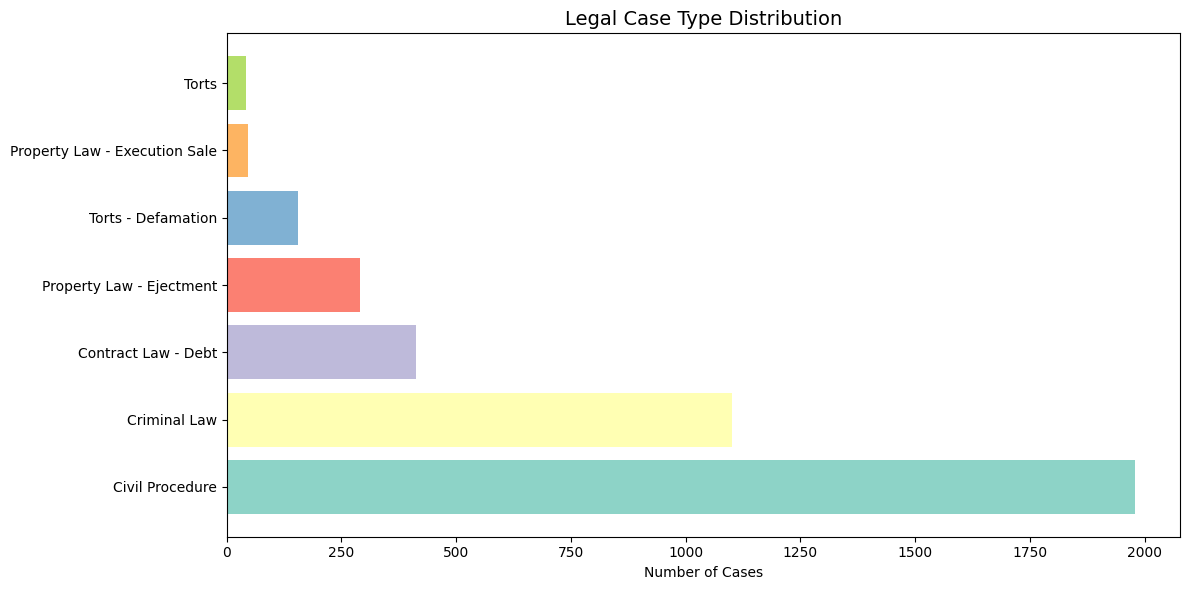

In [3]:
# Case type distribution
print("\n" + "=" * 70)
print("CASE TYPE DISTRIBUTION")
print("=" * 70)

case_type_dist = df['Case_Type'].value_counts()
for ct, count in case_type_dist.items():
    pct = count/len(df)*100
    bar = "█" * int(pct/2)
    print(f"{ct:<35} {count:>5} ({pct:>5.1f}%) {bar}")

# Visualize
plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(range(len(case_type_dist)))
plt.barh(range(len(case_type_dist)), case_type_dist.values, color=colors)
plt.yticks(range(len(case_type_dist)), case_type_dist.index)
plt.xlabel('Number of Cases')
plt.title('Legal Case Type Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('case_type_distribution.png', dpi=150)
plt.show()

In [4]:
# Verdict distribution
print("\n" + "=" * 70)
print("VERDICT DISTRIBUTION")
print("=" * 70)

verdict_dist = df['Verdict'].value_counts()
for v, count in verdict_dist.head(15).items():
    pct = count/len(df)*100
    print(f"{v:<35} {count:>5} ({pct:>5.1f}%)")

# Known vs Unknown verdicts
known_verdicts = df[df['Verdict'] != 'Verdict Unknown']
unknown_verdicts = df[df['Verdict'] == 'Verdict Unknown']

print(f"\n✅ Known Verdicts: {len(known_verdicts):,} ({len(known_verdicts)/len(df)*100:.1f}%)")
print(f"❌ Unknown Verdicts: {len(unknown_verdicts):,} ({len(unknown_verdicts)/len(df)*100:.1f}%)")

# Outcome analysis for known verdicts
print("\n⚖️ Case Outcomes (Known Verdicts Only):")
outcomes = known_verdicts['Verdict'].str.contains('AFFIRMED|REVERSED|SET ASIDE')
affirmed = known_verdicts['Verdict'].str.contains('AFFIRMED').sum()
reversed_count = known_verdicts['Verdict'].str.contains('REVERSED').sum()
set_aside = known_verdicts['Verdict'].str.contains('SET ASIDE').sum()

print(f"   Affirmed: {affirmed} ({affirmed/len(known_verdicts)*100:.1f}%)")
print(f"   Reversed: {reversed_count} ({reversed_count/len(known_verdicts)*100:.1f}%)")
print(f"   Set Aside: {set_aside} ({set_aside/len(known_verdicts)*100:.1f}%)")


VERDICT DISTRIBUTION
Denied                               1091 ( 27.1%)
Per Curiam: Judgment REVERSED with costs   512 ( 12.7%)
Judgment AFFIRMED                     428 ( 10.6%)
Judgment REVERSED with costs          309 (  7.7%)
Per Curiam: Judgment AFFIRMED         255 (  6.3%)
Per Curiam: Judgment AFFIRMED with costs   254 (  6.3%)
Legal Ruling (No Final Judgment)      215 (  5.3%)
Per Curiam: Judgment REVERSED         171 (  4.2%)
Judgment REVERSED                     161 (  4.0%)
Granted                               152 (  3.8%)
Judgment AFFIRMED with costs          130 (  3.2%)
Remanded                               68 (  1.7%)
Dismissed                              44 (  1.1%)
Case Dismissed                         33 (  0.8%)
Sustained                              17 (  0.4%)

✅ Known Verdicts: 4,026 (100.0%)
❌ Unknown Verdicts: 0 (0.0%)

⚖️ Case Outcomes (Known Verdicts Only):
   Affirmed: 1098 (27.3%)
   Reversed: 1214 (30.2%)
   Set Aside: 2 (0.0%)


In [5]:
# Sub-type distribution
print("\n" + "=" * 70)
print("SUB-TYPE DISTRIBUTION")
print("=" * 70)

subtype_dist = df['Sub_Type'].value_counts()
for st, count in subtype_dist.head(15).items():
    pct = count/len(df)*100
    print(f"{st:<25} {count:>5} ({pct:>5.1f}%)")

# Cross-tabulation: Case Type vs Sub-Type
print("\n" + "=" * 70)
print("CASE TYPE × SUB-TYPE MATRIX")
print("=" * 70)

cross_tab = pd.crosstab(df['Case_Type'], df['Sub_Type'], margins=True)
print(cross_tab)


SUB-TYPE DISTRIBUTION
Appeal                     1405 ( 34.9%)
General Criminal            816 ( 20.3%)
Demurrer                    555 ( 13.8%)
Promissory Note             254 (  6.3%)
Bond                        105 (  2.6%)
Ejectment                    96 (  2.4%)
Slander                      93 (  2.3%)
Title Dispute                91 (  2.3%)
Larceny                      67 (  1.7%)
Homicide                     66 (  1.6%)
Mortgage Foreclosure         66 (  1.6%)
Assault & Battery            53 (  1.3%)
Defamation                   49 (  1.2%)
Indictment                   48 (  1.2%)
General Property             37 (  0.9%)

CASE TYPE × SUB-TYPE MATRIX
Sub_Type                       Affray  Appeal  Assault & Battery  Attachment  \
Case_Type                                                                      
Civil Procedure                     0    1405                  0           1   
Contract Law - Debt                 0       0                  0           0   
Criminal Law 

In [6]:
# Citation analysis
print("\n" + "=" * 70)
print("CITATION NETWORK ANALYSIS")
print("=" * 70)

# Cases with most citations
top_cited = df.nlargest(10, 'Num_Citations')[['Case_ID', 'Case_Name', 'Num_Citations', 'Case_Type']]
print("Top 10 Most Cited Cases:")
for i, row in top_cited.iterrows():
    print(f"   {row['Case_ID']}: {row['Case_Name'][:50]}... ({row['Num_Citations']} citations)")

# Citation patterns by case type
print("\nAverage Citations by Case Type:")
citations_by_type = df.groupby('Case_Type')['Num_Citations'].mean().sort_values(ascending=False)
for ct, avg_cite in citations_by_type.head(10).items():
    print(f"   {ct:<30} {avg_cite:.2f} avg citations")

# Extract all unique cited cases
all_citations = []
for cites in df['Legal_Citations'].dropna():
    if isinstance(cites, str):
        all_citations.extend(cites.split('; '))

unique_citations = set(all_citations)
print(f"\n📚 Unique Citations in Corpus: {len(unique_citations):,}")


CITATION NETWORK ANALYSIS
Top 10 Most Cited Cases:
   230: 0230-01... (288 citations)
   83: 0083-01... (234 citations)
   353: 0353-01... (203 citations)
   128: 0128-01... (193 citations)
   569: 0569-01... (187 citations)
   662: 0662-01... (148 citations)
   614: 0614-01... (140 citations)
   127: 0127-01... (131 citations)
   382: 0382-01... (127 citations)
   673: 0673-01... (125 citations)

Average Citations by Case Type:
   Torts                          13.88 avg citations
   Contract Law - Debt            7.87 avg citations
   Property Law - Ejectment       7.58 avg citations
   Criminal Law                   7.53 avg citations
   Torts - Defamation             7.41 avg citations
   Civil Procedure                4.24 avg citations
   Property Law - Execution Sale  2.70 avg citations

📚 Unique Citations in Corpus: 12,974


In [9]:
print("Initial Shape:", df.shape)
print(df.head())

# ============================================================
# 3. BASIC CLEANING
# ============================================================

# Check duplicates
print("Duplicates check:", df.duplicated().sum())

# Check missing values
print("Missing values check:\n", df.isna().sum())


Initial Shape: (4026, 15)
   Case_ID Case_Name Source_Folder  Year                     Court  \
0       16   0016-01         file1  1818  Supreme Court of Indiana   
1      262   0262-01         file1  1823  Supreme Court of Indiana   
2      176   0176-01         file1  1822  Supreme Court of Indiana   
3      217   0217-01         file1  1822  Supreme Court of Indiana   
4      258   0258-01         file1  1823  Supreme Court of Indiana   

                                           Case_Text  Case_Text_Full_Length  \
0  Cole v. Driskell. Debt will He on the judgment...                   8971   
1  Findley v. Cooley. A vendee of real estate, ca...                   9242   
2  Savage and Others, Administrators of Prentiss,...                   1501   
3  Duerson and Others v. Bellows, Administrator. ...                   3521   
4  Wilcox v. Webb and Wife. In slander for words ...                   2771   

                         Verdict            Case_Type         Sub_Type  \
0  P

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Case_ID                4026 non-null   int64 
 1   Case_Name              4026 non-null   object
 2   Source_Folder          4026 non-null   object
 3   Year                   4026 non-null   int64 
 4   Court                  4026 non-null   object
 5   Case_Text              4026 non-null   object
 6   Case_Text_Full_Length  4026 non-null   int64 
 7   Verdict                4026 non-null   object
 8   Case_Type              4026 non-null   object
 9   Sub_Type               4026 non-null   object
 10  Num_Citations          4026 non-null   int64 
 11  Legal_Citations        4026 non-null   object
 12  Decision_Date          4026 non-null   object
 13  First_Page             4026 non-null   int64 
 14  Last_Page              4026 non-null   object
dtypes: int64(5), object(1